# Chapter 1 — The Neuron

**The building block this notebook untangles:** every neural network, no matter how
large, is made of the same tiny unit repeated millions of times: a **neuron**. If you
understand one neuron completely, you understand what every network is doing —
just at scale.

A neuron does three things, in order:

1. **Weighted sum** — multiply every input by a weight (how much that input matters)
   and add them up.
2. **Add a bias** — a nudge that shifts the decision, independent of the inputs.
3. **Activation** — squash the result into the output the neuron actually reports.

$$z = (x_1 w_1 + x_2 w_2 + \dots + x_n w_n) + b \qquad a = \text{activation}(z)$$

We'll keep one running problem for this whole chapter series: **can a neuron learn
logic gates?** We start with OR — and in Chapter 7 we'll come back to XOR, which a
single neuron famously *cannot* learn (that failure is the whole reason "deep"
learning needs more than one neuron).

## Part 1 — A neuron by hand

The OR gate: output 1 if *either* input is 1.

| x1 | x2 | OR |
|----|----|----|
| 0  | 0  | 0  |
| 0  | 1  | 1  |
| 1  | 0  | 1  |
| 1  | 1  | 1  |

Let's hand-pick weights and a bias and see if a single neuron can reproduce this
table — no learning yet, just plugging numbers into the formula above.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

def step(z):
    """The simplest possible activation: fire (1) or don't (0)."""
    return (z >= 0).astype(int)

def neuron(x, w, b, activation=step):
    z = np.dot(x, w) + b
    return activation(z), z

w = np.array([1.0, 1.0])
b = -0.5

print(f"{'x1':>3} {'x2':>3} {'z':>6} {'output':>7} {'target':>7}")
for x, target in zip(X_or, y_or):
    out, z = neuron(x, w, b)
    print(f"{x[0]:>3} {x[1]:>3} {z:>6.2f} {out:>7} {target:>7}")

 x1  x2      z  output  target
  0   0  -0.50       0       0
  0   1   0.50       1       1
  1   0   0.50       1       1
  1   1   1.50       1       1


It matches every row. Two weights of `1.0` mean "each input counts equally," and a
bias of `-0.5` means "fire unless *nothing* is on." That's the whole gate, encoded
in three numbers.

## Part 2 — Why the bias matters, visually

The neuron's decision boundary is the line `w1*x1 + w2*x2 + b = 0`. Everything on
one side fires, everything on the other doesn't. Let's plot the OR points and that
line, then see what happens if we remove the bias (`b = 0`).

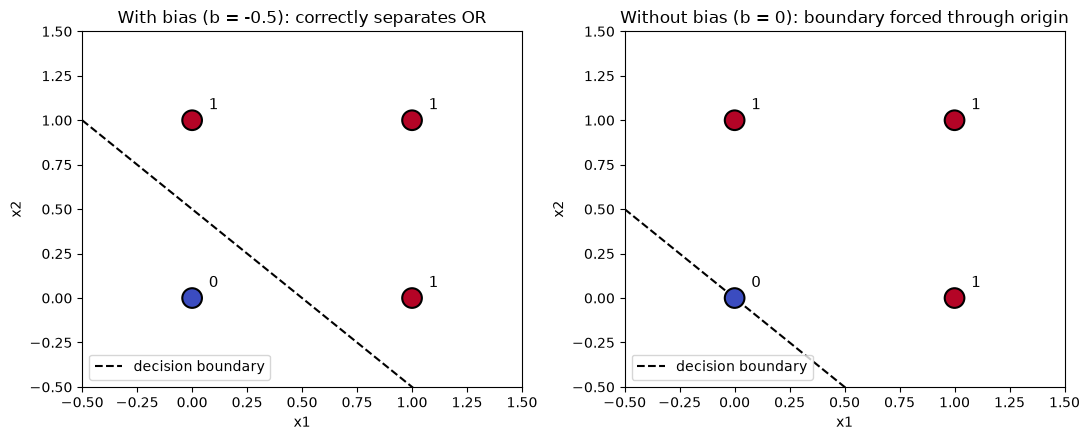

In [2]:
def plot_gate(X, y, w, b, title, ax):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=200,
               edgecolors='black', linewidths=1.5, zorder=3)
    for (x1, x2), label in zip(X, y):
        ax.annotate(str(label), (x1, x2), textcoords="offset points",
                    xytext=(12, 8), fontsize=11)

    xs = np.linspace(-0.5, 1.5, 50)
    if w[1] != 0:
        ys = -(w[0] * xs + b) / w[1]
        ax.plot(xs, ys, 'k--', label='decision boundary')
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_title(title)
    ax.legend(loc='lower left')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_gate(X_or, y_or, w=np.array([1.0, 1.0]), b=-0.5,
          title='With bias (b = -0.5): correctly separates OR', ax=axes[0])
plot_gate(X_or, y_or, w=np.array([1.0, 1.0]), b=0.0,
          title='Without bias (b = 0): boundary forced through origin', ax=axes[1])
plt.tight_layout()
plt.show()

Without a bias, the decision line is forced to pass through the origin — the
neuron can only rotate its boundary, never shift it. For OR that happens to
still work if you nudge the weights, but in general the bias is what lets the
neuron place its boundary *anywhere*, not just through `(0, 0)`. That's why real
neurons always carry one.

## Part 3 — Different weights, different gate

The *only* thing that changed between "this neuron computes OR" and "this neuron
computes AND" is the numbers. Same three lines of arithmetic, different weights.

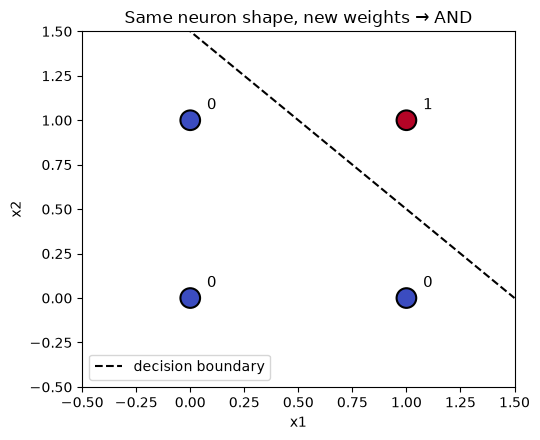

AND predictions: [np.int64(0), np.int64(0), np.int64(0), np.int64(1)]


In [3]:
y_and = np.array([0, 0, 0, 1])

w_and = np.array([1.0, 1.0])
b_and = -1.5   # only fires when BOTH inputs are on

fig, ax = plt.subplots(figsize=(5.5, 4.5))
plot_gate(X_or, y_and, w=w_and, b=b_and, title='Same neuron shape, new weights → AND', ax=ax)
plt.tight_layout()
plt.show()

print("AND predictions:", [neuron(x, w_and, b_and)[0] for x in X_or])

## Recap

A neuron is `activation(weighted sum + bias)`. Change the weights and bias, and
the *same* neuron represents a different function. So far we've been choosing
the weights ourselves by inspection — that clearly won't scale to problems where
we don't already know the answer. Chapters 4–6 build the machinery (loss,
gradients, gradient descent) that finds these weights automatically.

First, though: the `step` activation we used is too blunt to train with (it has
zero useful gradient — Chapter 2 explains why that matters, and introduces the
activations real networks actually use).

**Next:** [Chapter 2 — Activation Functions](02_activation_functions.ipynb)